<h1 style="color:#56B4E9;">Week 4 - Day 3</h1>

<h2 style="color:#0072B2;">Bias-Variance & Diagnosing Model Fit</h2>

<h3 style="color:#009E73;">Breast Cancer Classification</h3>

Today I will diagnose model fit by comparing performance on the training and validation sets.

The goal is not to judge a model from one score. I will deliberately create both overfitting and underfitting, diagnose each case from the observed scores, and then reduce the complexity of the overfit model to study how the train-validation gap changes.

<span style="color:#D55E00;"><b>Important:</b></span>  
The final test set will remain untouched while making these modeling decisions.

In [15]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)


# Keep the same target definition used in Day 1 and Day 2
# 1 = Malignant, 0 = Benign
y = pd.Series(
    (data.target == 0).astype(int),
    name='Malignant'
)

X_temp , X_test ,y_temp,y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train ,X_val,y_train ,y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Final test:", X_test.shape)


Train: (341, 30)
Validation: (114, 30)
Final test: (114, 30)


<h2 style="color:#0072B2;">Experiment 1 — Can an Unrestricted Decision Tree Overfit?</h2>

**Question:**  
What happens when I allow a Decision Tree to grow without setting a maximum depth?

I will deliberately use an unrestricted tree:

`max_depth = None`

This gives the model enough flexibility to create many splits and potentially fit details that are specific to the training data.

To diagnose the result, I will compare:

- **Training F1**
- <span style="color:#E69F00;"><b>Validation F1</b></span>
- **Train–validation gap**

I will also inspect the actual tree depth and number of leaves as evidence of the model's complexity.

<span style="color:#D55E00;"><b>The final test set will not be used in this experiment.</b></span>

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

overfit_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

overfit_tree.fit(X_train , y_train)

overfit_train_pred = overfit_tree.predict(X_train)
train_f1 = f1_score(y_train,overfit_train_pred)

pred_val = overfit_tree.predict(X_val)
val_f1 = f1_score(y_val , pred_val)

gap = train_f1 - val_f1
print(f"Tree depth: {overfit_tree.get_depth()}")
print(f"Number of leaves: {overfit_tree.get_n_leaves()}")

print(f"\nTraining F1:   {train_f1:.4f}")
print(f"Validation F1: {val_f1:.4f}")
print(f"Gap:           {gap:.4f}")


Tree depth: 6
Number of leaves: 17

Training F1:   1.0000
Validation F1: 0.8764
Gap:           0.1236


<h2 style="color:#0072B2;">Diagnosis — Overfitting</h2>

The unrestricted Decision Tree produced:

- **Training F1 = 1.0000**
- <span style="color:#E69F00;"><b>Validation F1 = 0.8764</b></span>
- **Train–validation gap = 0.1236**
- **Tree depth = 6**
- **Number of leaves = 17**

The model achieved perfect F1 on the training data, but its performance dropped noticeably on unseen validation data.

This gap suggests that the unrestricted tree fitted patterns that were useful for the training samples but did not generalize equally well to the validation set.

The tree depth and number of leaves describe the model's complexity, but they do not prove overfitting by themselves. The diagnosis comes from the combination of **very high training performance and substantially lower validation performance**.

<span style="color:#009E73;"><b>Diagnosis:</b></span>  
This model shows clear evidence of **overfitting (high variance behavior)**.

<h2 style="color:#0072B2;">Experiment 2 — What Happens When the Model Is Too Simple?</h2>

**Question:**  
What happens if I restrict the Decision Tree so strongly that it cannot capture enough of the pattern?

I will use:

`max_depth = 1`

This allows only a very simple decision structure.

If the model underfits, I expect both **training** and <span style="color:#E69F00;"><b>validation</b></span> performance to be limited rather than seeing a very high training score with a large gap.

<span style="color:#D55E00;"><b>The final test set remains untouched.</b></span>

In [17]:
underfit_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

underfit_tree.fit(X_train, y_train)

underfit_train_pred = underfit_tree.predict(X_train)
underfit_val_pred = underfit_tree.predict(X_val)

underfit_train_f1 = f1_score(y_train, underfit_train_pred)
underfit_val_f1 = f1_score(y_val, underfit_val_pred)

underfit_gap = underfit_train_f1 - underfit_val_f1

print(f"Tree depth: {underfit_tree.get_depth()}")
print(f"Number of leaves: {underfit_tree.get_n_leaves()}")

print(f"\nTraining F1:   {underfit_train_f1:.4f}")
print(f"Validation F1: {underfit_val_f1:.4f}")
print(f"Gap:           {underfit_gap:.4f}")

Tree depth: 1
Number of leaves: 2

Training F1:   0.9024
Validation F1: 0.9024
Gap:           0.0000


<h2 style="color:#0072B2;">Diagnosis — Underfitting</h2>

The depth-1 Decision Tree produced:

- **Training F1 = 0.9024**
- <span style="color:#E69F00;"><b>Validation F1 = 0.9024</b></span>
- **Train–validation gap = 0.0000**
- **Tree depth = 1**
- **Number of leaves = 2**

Unlike the unrestricted tree, this model does not show a generalization gap. However, the small gap does not mean the model is well fitted.

Its training performance is already limited, which means the model is too restricted to capture enough of the pattern present in the training data.

Its training F1 of **0.9024** is substantially lower than the **1.0000 training F1** achieved by the unrestricted tree on the same training data.

This shows that the depth-1 constraint limits the model's ability to fit patterns that a more flexible tree can capture.

<span style="color:#009E73;"><b>Diagnosis:</b></span>  
The depth-1 tree shows **underfitting (high-bias behavior)**: both training and validation performance are limited because the model is too simple.

,Model,Training F1,Validation F1,Gap
0,Depth = 1,0.9024,0.9024,0.0000
1,Unrestricted,1.0000,0.8764,0.1236


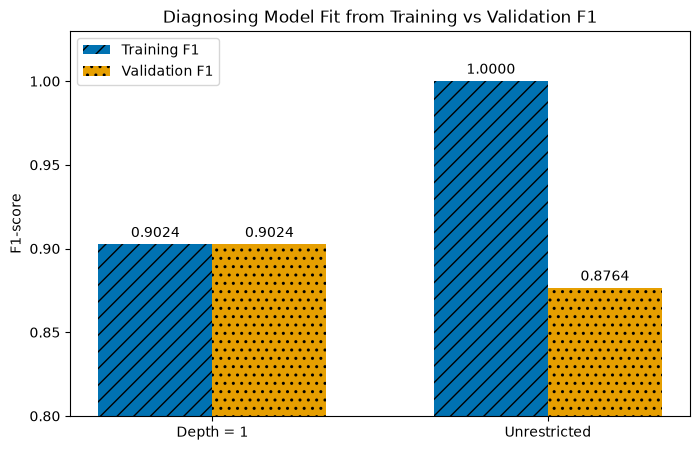

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fit_comparison = pd.DataFrame({
    "Model": ["Depth = 1", "Unrestricted"],
    "Training F1": [underfit_train_f1, train_f1],
    "Validation F1": [underfit_val_f1, val_f1]
})

fit_comparison["Gap"] = (
    fit_comparison["Training F1"]
    - fit_comparison["Validation F1"]
)

display(fit_comparison.round(4))

x = np.arange(len(fit_comparison))
width = 0.34

fig, ax = plt.subplots(figsize=(8, 5))

train_bars = ax.bar(
    x - width/2,
    fit_comparison["Training F1"],
    width,
    label="Training F1",
    color="#0072B2",
    hatch="//"
)

val_bars = ax.bar(
    x + width/2,
    fit_comparison["Validation F1"],
    width,
    label="Validation F1",
    color="#E69F00",
    hatch=".."
)

ax.set_title("Diagnosing Model Fit from Training vs Validation F1")
ax.set_ylabel("F1-score")
ax.set_xticks(x)
ax.set_xticklabels(fit_comparison["Model"])
ax.set_ylim(0.80, 1.03)
ax.legend()

ax.bar_label(train_bars, fmt="%.4f", padding=3)
ax.bar_label(val_bars, fmt="%.4f", padding=3)

plt.show()

<h2 style="color:#0072B2;">What Did the Comparison Reveal?</h2>

The two models fail in opposite ways.

- The **depth-1 tree** has almost no train–validation gap, but its training F1 is already limited at **0.9024**. The model is too simple to fit the available training pattern well.
- The **unrestricted tree** reaches **1.0000 training F1**, but validation F1 falls to **0.8764**, creating a gap of **0.1236**.

<span style="color:#009E73;"><b>Key idea:</b></span>  
A small train–validation gap is not automatically desirable. Model fit must be diagnosed using both the **performance level** and the **gap**.

<h2 style="color:#0072B2;">Experiment 3 — How Does Model Complexity Change the Fit?</h2>

As tree depth increases, model flexibility also increases.

Conceptually, prediction error is often described as:

$$
\text{Expected Error}
=
\text{Bias}^2
+
\text{Variance}
+
\text{Irreducible Noise}
$$

A very simple model tends toward **higher bias**, while excessive flexibility can increase **variance**.

Because this is a classification experiment evaluated with F1-score, I will not calculate bias and variance directly from this equation. Instead, I will observe their practical symptoms through **training F1, validation F1, and the train-validation gap**.

**Question:**  
Can I find a depth that fits the training data well without creating the large generalization gap seen in the unrestricted tree?

In [19]:
depth_results = []

for depth in range(1, 7):
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_predictions = tree.predict(X_train)
    val_predictions = tree.predict(X_val)

    depth_train_f1 = f1_score(y_train, train_predictions)
    depth_val_f1 = f1_score(y_val, val_predictions)

    depth_results.append({
        "Max Depth": depth,
        "Training F1": depth_train_f1,
        "Validation F1": depth_val_f1,
        "Gap": depth_train_f1 - depth_val_f1
    })

depth_results = pd.DataFrame(depth_results)

display(depth_results.round(4))

,Max Depth,Training F1,Validation F1,Gap
0,1,0.9024,0.9024,0.0000
1,2,0.9308,0.8571,0.0736
2,3,0.9762,0.8941,0.0821
3,4,0.9881,0.8636,0.1245
4,5,0.9960,0.9091,0.0870
5,6,1.0000,0.8764,0.1236


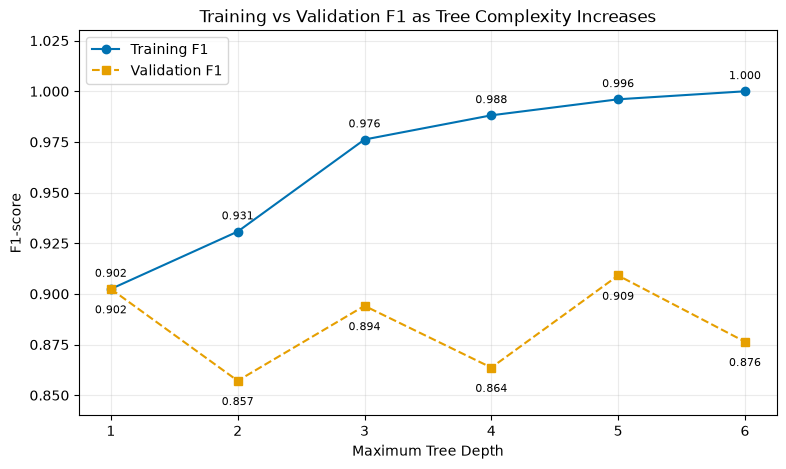

In [20]:
plt.figure(figsize=(9, 5))

plt.plot(
    depth_results["Max Depth"],
    depth_results["Training F1"],
    marker="o",
    linestyle="-",
    color="#0072B2",
    label="Training F1"
)

plt.plot(
    depth_results["Max Depth"],
    depth_results["Validation F1"],
    marker="s",
    linestyle="--",
    color="#E69F00",
    label="Validation F1"
)

for _, row in depth_results.iterrows():
    plt.text(
        row["Max Depth"],
        row["Training F1"] + 0.006,
        f'{row["Training F1"]:.3f}',
        ha="center",
        fontsize=8
    )

    plt.text(
        row["Max Depth"],
        row["Validation F1"] - 0.012,
        f'{row["Validation F1"]:.3f}',
        ha="center",
        fontsize=8
    )

plt.xlabel("Maximum Tree Depth")
plt.ylabel("F1-score")
plt.title("Training vs Validation F1 as Tree Complexity Increases")
plt.xticks(depth_results["Max Depth"])
plt.ylim(0.84, 1.03)
plt.legend()
plt.grid(alpha=0.25)

plt.show()

<h2 style="color:#0072B2;">Interpreting the Bias-Variance Trade-off</h2>

Increasing tree depth consistently improved the model's ability to fit the training data, from **0.902 F1 at depth 1** to **1.000 F1 at depth 6**.

Validation performance did not follow the same pattern. It fluctuated as complexity increased and reached its highest observed value at **depth 5 (F1 = 0.909)** before dropping to **0.876 at depth 6**.

This shows why training performance alone cannot guide model complexity.

At depth 6, the tree achieved perfect training performance but produced a large train-validation gap of approximately **0.124**.

Reducing the maximum depth to 5 slightly reduced training performance to **0.996**, while validation F1 improved to **0.909** and the gap decreased to approximately **0.087**.

<span style="color:#009E73;"><b>Key idea:</b></span>  
Increasing complexity improved the model's ability to fit the training data, reducing the symptoms associated with high bias.

However, excessive complexity produced a larger train-validation gap, which is evidence of high-variance behavior.

The useful region is therefore not the model with the highest training score, but one that balances fitting ability with generalization.

<h2 style="color:#0072B2;">Fixing the Underfit Tree</h2>

The depth-1 tree was too restricted:

- **Training F1 = 0.9024**
- <span style="color:#E69F00;"><b>Validation F1 = 0.9024</b></span>

Increasing the allowed tree depth gave the model more flexibility to capture patterns that the depth-1 model could not represent.

At `max_depth = 5`:

- **Training F1 = 0.9960**
- <span style="color:#E69F00;"><b>Validation F1 = 0.9091</b></span>

<span style="color:#009E73;"><b>Diagnosis and fix:</b></span>  
Relaxing the overly restrictive depth constraint reduced the symptoms of high bias by allowing the model to fit the training data much better.

However, increasing complexity also introduced a larger train-validation gap. This demonstrates the bias-variance trade-off: fixing underfitting does not mean increasing complexity without limit; the goal is to increase flexibility only enough to achieve a better balance.

In [21]:
constrained_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

constrained_tree.fit(X_train, y_train)

constrained_train_pred = constrained_tree.predict(X_train)
constrained_val_pred = constrained_tree.predict(X_val)

constrained_train_f1 = f1_score(y_train, constrained_train_pred)
constrained_val_f1 = f1_score(y_val, constrained_val_pred)

constrained_gap = constrained_train_f1 - constrained_val_f1

print(f"Training F1:   {constrained_train_f1:.4f}")
print(f"Validation F1: {constrained_val_f1:.4f}")
print(f"Gap:           {constrained_gap:.4f}")

Training F1:   0.9960
Validation F1: 0.9091
Gap:           0.0870


<h2 style="color:#0072B2;">Fixing the Overfit Tree</h2>

The unrestricted tree showed a large train-validation gap:

- **Training F1 = 1.0000**
- <span style="color:#E69F00;"><b>Validation F1 = 0.8764</b></span>
- **Gap = 0.1236**

After limiting the tree to `max_depth = 5`:

- **Training F1 = 0.9960**
- <span style="color:#E69F00;"><b>Validation F1 = 0.9091</b></span>
- **Gap = 0.0870**

Reducing complexity caused only a small decrease in training F1 of **0.0040**, while validation F1 improved by **0.0327** and the train-validation gap decreased by **0.0366**.

<span style="color:#009E73;"><b>Decision:</b></span>  
Reducing tree depth improved the balance between fitting the training data and generalizing to unseen validation data.

This does not prove that depth 5 is universally optimal. It is the strongest balance observed among the depths evaluated in this experiment.

<span style="color:#D55E00;"><b>The final test set was not used to make this decision.</b></span>

,Model,Training F1,Validation F1,Gap
0,Unrestricted,1.000,0.8764,0.1236
1,Depth = 5,0.996,0.9091,0.0870


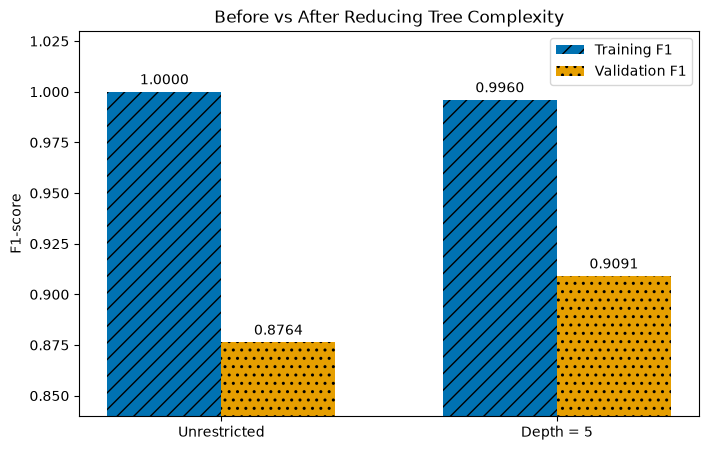

In [22]:
fix_comparison = pd.DataFrame({
    "Model": ["Unrestricted", "Depth = 5"],
    "Training F1": [train_f1, constrained_train_f1],
    "Validation F1": [val_f1, constrained_val_f1],
    "Gap": [gap, constrained_gap]
})

display(fix_comparison.round(4))

x = np.arange(len(fix_comparison))
width = 0.34

fig, ax = plt.subplots(figsize=(8, 5))

train_bars = ax.bar(
    x - width / 2,
    fix_comparison["Training F1"],
    width,
    label="Training F1",
    color="#0072B2",
    hatch="//"
)

val_bars = ax.bar(
    x + width / 2,
    fix_comparison["Validation F1"],
    width,
    label="Validation F1",
    color="#E69F00",
    hatch=".."
)

ax.set_title("Before vs After Reducing Tree Complexity")
ax.set_ylabel("F1-score")
ax.set_xticks(x)
ax.set_xticklabels(fix_comparison["Model"])
ax.set_ylim(0.84, 1.03)
ax.legend()

ax.bar_label(train_bars, fmt="%.4f", padding=3)
ax.bar_label(val_bars, fmt="%.4f", padding=3)

plt.show()

<h2 style="color:#0072B2;">Did Reducing Complexity Fix the Overfitting?</h2>

Yes. Limiting the tree depth improved its behavior on unseen validation data.

The unrestricted tree achieved:

- **Training F1 = 1.0000**
- <span style="color:#E69F00;"><b>Validation F1 = 0.8764</b></span>
- **Gap = 0.1236**

After reducing the maximum depth to 5:

- **Training F1 = 0.9960**
- <span style="color:#E69F00;"><b>Validation F1 = 0.9091</b></span>
- **Gap = 0.0870**

The training score decreased only slightly, while validation performance improved and the train-validation gap became smaller.

<span style="color:#009E73;"><b>Decision:</b></span>  
Reducing model complexity successfully reduced the overfitting observed in the unrestricted tree.

Depth 5 is not claimed to be universally optimal; it is the strongest balance observed among the depths evaluated in this experiment.

<span style="color:#D55E00;"><b>The final test set remained untouched and was not used to choose the tree depth.</b></span>

<h2 style="color:#0072B2;">Regularization — Ridge (L2) and Lasso (L1)</h2>

Reducing tree depth is one way to control model complexity.  
For linear models, another common approach is **regularization**, where a penalty is added to the objective function to discourage unnecessarily large coefficients.

The general idea is:

$$
\text{Objective}
=
\text{Prediction Loss}
+
\text{Regularization Penalty}
$$

The penalty creates a trade-off between fitting the training data closely and keeping the model simpler.

---

### Ridge — L2 Regularization

Ridge adds a penalty based on the squared magnitude of the coefficients:

$$
\text{Objective}_{L2}
=
\text{Prediction Loss}
+
\alpha \sum_{j=1}^{p} w_j^2
$$

Equivalently:

$$
\text{Objective}_{L2}
=
\text{Prediction Loss}
+
\alpha ||w||_2^2
$$

The parameter $\alpha$ controls the strength of the penalty.

As $\alpha$ increases:

$$
\alpha \uparrow
\Rightarrow
\text{stronger penalty}
\Rightarrow
|w_j| \downarrow
\Rightarrow
\text{less model flexibility}
$$

Ridge usually shrinks coefficients toward zero, but it does not typically force them to become exactly zero.

---

### Lasso — L1 Regularization

Lasso uses the absolute magnitude of the coefficients:

$$
\text{Objective}_{L1}
=
\text{Prediction Loss}
+
\alpha \sum_{j=1}^{p}|w_j|
$$

Equivalently:

$$
\text{Objective}_{L1}
=
\text{Prediction Loss}
+
\alpha ||w||_1
$$

Lasso also reduces coefficient magnitudes, but unlike Ridge, it can push some coefficients exactly to zero.

When a coefficient becomes:

$$
w_j = 0
$$

that feature no longer contributes to the model's prediction.

Therefore, Lasso can perform a form of **automatic feature selection**.

---

### Why Do L1 and L2 Behave Differently?

The difference comes from how each penalty changes as a coefficient changes.

For L2:

$$
\frac{\partial}{\partial w_j}
\left(\alpha w_j^2\right)
=
2\alpha w_j
$$

The strength of the L2 penalty depends on the magnitude of the coefficient.

A large coefficient receives a stronger penalty.

However, as $w_j$ approaches zero:

$$
2\alpha w_j \rightarrow 0
$$

so the shrinkage effect also becomes smaller.

This is why Ridge usually produces **small but non-zero coefficients** rather than eliminating them completely.

For L1:

$$
\frac{\partial}{\partial w_j}
\left(\alpha |w_j|\right)
=
\alpha \operatorname{sign}(w_j)
$$

for non-zero $w_j$.

Unlike L2, the magnitude of this shrinkage pressure does not decrease as the coefficient gets smaller.

This makes it possible for Lasso to push some coefficients all the way to:

$$
w_j = 0
$$

<span style="color:#009E73;"><b>Practical consequence:</b></span>  

- **L2 mainly shrinks coefficients**, especially large ones.
- **L1 can shrink coefficients and eliminate some of them completely.**
- A coefficient of zero means that the corresponding feature has no contribution to the prediction.
- Therefore, L1 can effectively perform **feature selection**.

---

<span style="color:#009E73;"><b>Key idea:</b></span>  

Regularization reduces model flexibility by penalizing coefficient magnitude.

L2 usually distributes the shrinkage across the coefficients, while L1 can create sparse models by setting some coefficients exactly to zero.

For today's Breast Cancer classification experiment, I reduced Decision Tree complexity using `max_depth` rather than applying Ridge or Lasso directly.

The Ridge and Lasso equations are included to understand the regularization concepts required for this lesson.

<h2 style="color:#0072B2;">Final Diagnosis</h2>

This experiment showed three different model-fit behaviors.

### Underfitting

With `max_depth = 1`:

- **Training F1 = 0.9024**
- <span style="color:#E69F00;"><b>Validation F1 = 0.9024</b></span>
- **Gap = 0.0000**

The train-validation gap was almost zero, but the training performance itself was limited. The model was too simple to capture enough of the pattern in the training data.

### Overfitting

With an unrestricted Decision Tree:

- **Training F1 = 1.0000**
- <span style="color:#E69F00;"><b>Validation F1 = 0.8764</b></span>
- **Gap = 0.1236**

The model fitted the training data perfectly, but this performance did not generalize equally well to the validation set. The large gap provided evidence of overfitting.

### Reducing the Overfitting

After limiting the tree to `max_depth = 5`:

- **Training F1 = 0.9960**
- <span style="color:#E69F00;"><b>Validation F1 = 0.9091</b></span>
- **Gap = 0.0870**

Reducing complexity sacrificed only a small amount of training performance while improving validation F1 and reducing the train-validation gap.

<span style="color:#009E73;"><b>Key lesson:</b></span>  
Model fit cannot be diagnosed from validation performance or the train-validation gap alone. I need to consider both the **level of performance** and the **difference between training and validation performance**.

A very small gap can indicate underfitting when both scores are limited, while an extremely high training score combined with weaker validation performance can indicate overfitting.

The bias-variance trade-off is therefore about finding enough model flexibility to capture the underlying pattern without fitting training-specific details that do not generalize.

<span style="color:#009E73;"><b>Final decision:</b></span>  
For this experiment, limiting the Decision Tree to `max_depth = 5` provided a better balance than either the depth-1 or unrestricted tree. This is a decision based on the evaluated depths and validation evidence, not a claim that depth 5 is universally optimal.

<span style="color:#D55E00;"><b>The final test set remained untouched throughout all model-fit diagnosis and complexity decisions.</b></span>